<a href="https://colab.research.google.com/github/aisha13dikko-sudo/AISD-poverty-Nigeria-Context/blob/master/25084356_Dikko_Task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Coursework 1 — Task 1: Adversarial Robustness (MNIST)**

Three MNIST classifiers were trained to achieve accuracy >98% on the test set. The robustness of the models to the Fast Gradient Method (FGM) and Projected Gradient Descent (PGD) attacks were tested. The robustness of the trained models is reported in terms of the test accuracy under attack and the average perturbation size. The test accuracy under attack and the average perturbation size for each model under each attack at different perturbation strength are plotted and discussed.

In [ ]:
# ==== Setup ====
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np, random, time
from tqdm.auto import tqdm

# Reproducibility
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

**Dataset and preprocessing**

We train models on the MNIST dataset with standard normalisation. The most common training protocol for MNIST is to train and evaluate models on normalised inputs. It also has the side effect of improving the stability of optimisation.

In [ ]:
# MNIST normalization
mnist_mean, mnist_std = 0.1307, 0.3081

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((mnist_mean,), (mnist_std,))
])

train_ds = datasets.MNIST(root=".", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root=".", train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False, num_workers=0, pin_memory=True)

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.56MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 135kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.6MB/s]


**Model architectures**

We train three different networks with different architectures, so that we have something to compare to. Model A is a basic CNN. Model B is a deeper network that uses BatchNorm. Model C is a more regularized version (with dropout and weight decay).

**Model A : Simple CNN (baseline)**

In [ ]:
class ModelA_SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.fc1   = nn.Linear(64*7*7, 128)
        self.fc2   = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))      # 28x28
        x = F.max_pool2d(x, 2)         # 14x14
        x = F.relu(self.conv2(x))      # 14x14
        x = F.max_pool2d(x, 2)         # 7x7
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

**Model B: Deeper CNN + BatchNorm (capacity + stabilisation)**

In [ ]:
class ModelB_DeepBN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 128, 3, padding=1)
        self.bn4   = nn.BatchNorm2d(128)

        self.fc1   = nn.Linear(128*7*7, 256)
        self.fc2   = nn.Linear(256, 10)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.max_pool2d(x, 2)         # 14x14

        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = F.max_pool2d(x, 2)         # 7x7

        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

**Model C: Regularised CNN (Dropout + weight decay later)**




In [ ]:
class ModelC_RegDropout(nn.Module):
    def __init__(self, p=0.3):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.drop2d = nn.Dropout2d(p)
        self.drop   = nn.Dropout(p)
        self.fc1   = nn.Linear(128*7*7, 256)
        self.fc2   = nn.Linear(256, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)         # 14x14
        x = F.relu(self.conv2(x))
        x = self.drop2d(x)
        x = F.max_pool2d(x, 2)         # 7x7
        x = F.relu(self.conv3(x))      # 7x7
        x = x.view(x.size(0), -1)
        x = self.drop(F.relu(self.fc1(x)))
        return self.fc2(x)

**Training procedure**

Models are trained with cross-entropy loss using the Adam optimiser. We report training and test accuracy for each epoch, and only keep the models with a test accuracy above 98% as requested.

**Training +Evaluation loop**

In [ ]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct, total, loss_sum = 0, 0, 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = F.cross_entropy(logits, y, reduction="sum")
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)
        loss_sum += loss.item()
    return loss_sum/total, correct/total

def train_model(model, epochs=5, lr=1e-3, weight_decay=0.0):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    for ep in range(1, epochs+1):
        model.train()
        t0 = time.time()
        for x, y in tqdm(train_loader, desc=f"Epoch {ep}/{epochs}", leave=False):
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            logits = model(x)
            loss = F.cross_entropy(logits, y)
            loss.backward()
            opt.step()

        tr_loss, tr_acc = evaluate(model, train_loader)
        te_loss, te_acc = evaluate(model, test_loader)
        print(f"Epoch {ep}: train acc={tr_acc*100:.2f}% | test acc={te_acc*100:.2f}% | time={time.time()-t0:.1f}s")

    return model

**Training all models**

In [ ]:
modelA = train_model(ModelA_SmallCNN(), epochs=5, lr=1e-3)
modelB = train_model(ModelB_DeepBN(),   epochs=5, lr=1e-3)
modelC = train_model(ModelC_RegDropout(p=0.3), epochs=6, lr=1e-3, weight_decay=1e-4)

# Final test accuracies
for name, m in [("A", modelA), ("B", modelB), ("C", modelC)]:
    _, acc = evaluate(m, test_loader)
    print(f"Model {name} final test accuracy: {acc*100:.2f}%")

Epoch 1/5:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1: train acc=98.61% | test acc=98.46% | time=28.0s


Epoch 2/5:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 2: train acc=99.09% | test acc=99.01% | time=26.6s


Epoch 3/5:   0%|          | 0/469 [00:00<?, ?it/s]

...

Epoch 4: train acc=99.39% | test acc=98.94% | time=26.5s


Epoch 5/6:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 5: train acc=99.60% | test acc=99.10% | time=26.4s


Epoch 6/6:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 6: train acc=99.45% | test acc=99.08% | time=26.4s
Model A final test accuracy: 98.93%
Model B final test accuracy: 99.29%
Model C final test accuracy: 99.08%


In [ ]:
torch.save(modelA.state_dict(), "mnist_modelA.pth")
torch.save(modelB.state_dict(), "mnist_modelB.pth")
torch.save(modelC.state_dict(), "mnist_modelC.pth")
print("Saved: mnist_modelA.pth, mnist_modelB.pth, mnist_modelC.pth")

Saved: mnist_modelA.pth, mnist_modelB.pth, mnist_modelC.pth


**Task 1.2**


 **ART setup **


Adversarial Robustness Toolbox (ART) integration
We use the Adversarial Robustness Toolbox to generate adversarial examples in a standardized way. We wrap our models to turn them into ART classifiers. Our attacks are defined in the pixel space of [0,1] and ART does the necessary preprocessing that was done during training via the preprocessing interface.

In [ ]:
!pip -q install adversarial-robustness-toolbox

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 7.4 MB/s eta 0:00:00


In [ ]:
import numpy as np
import torch
import torch.nn as nn
from art.estimators.classification import PyTorchClassifier

# MNIST preprocessing used in your loader
mnist_mean, mnist_std = 0.1307, 0.3081

def make_art_classifier(pytorch_model):
    pytorch_model = pytorch_model.to(device)
    pytorch_model.eval()

    loss_fn = nn.CrossEntropyLoss()
    # Optimizer is required by the wrapper; not used for our attacks directly
    optimizer = torch.optim.Adam(pytorch_model.parameters(), lr=1e-3)

    classifier = PyTorchClassifier(
        model=pytorch_model,
        loss=loss_fn,
        optimizer=optimizer,
        input_shape=(1, 28, 28),
        nb_classes=10,
        clip_values=(0.0, 1.0),                     # attacks operate in pixel space
        preprocessing=(mnist_mean, mnist_std),      # ART will normalise before forward pass
        device_type="gpu" if device == "cuda" else "cpu",
    )
    return classifier

clfA = make_art_classifier(modelA)
clfB = make_art_classifier(modelB)
clfC = make_art_classifier(modelC)

**Sample selection**

Selecting the evaluation subset (n=100)
In this section we attempt to evaluate the robustness of deep learning models. We first sample 100 test images with random labels using a fixed seed for reproducibility. The samples are drawn from the raw MNIST test set in pixel space [0,1] which is the input domain that the attack constraints assume.

In [ ]:
from torchvision import datasets, transforms

# Raw MNIST (no normalisation) for ART input space
raw_transform = transforms.ToTensor()
raw_test_ds = datasets.MNIST(root=".", train=False, download=True, transform=raw_transform)

rng = np.random.default_rng(42)  # fixed seed
idx = rng.choice(len(raw_test_ds), size=100, replace=False)

x = np.stack([raw_test_ds[i][0].numpy() for i in idx]).astype(np.float32)  # (100,1,28,28) in [0,1]
y = np.array([raw_test_ds[i][1] for i in idx]).astype(np.int64)

print(x.shape, y.shape, x.min(), x.max())

(100, 1, 28, 28) (100,) 0.0 1.0


**Attacks + metrics**

Attacks and robustness metrics
FGSM and PGD attacks are tested. The robustness is measured in two ways: (i) the accuracy on adversarial examples, and (ii) the average distortion in terms of L∞ and L2 metrics in the pixel space.

In [ ]:
from art.attacks.evasion import FastGradientMethod, ProjectedGradientDescent

eps_grid = [0.05, 0.10, 0.15, 0.20]   # in pixel space (since clip_values=(0,1))
pgd_steps = 40
pgd_step_size = 0.01                 # alpha

def make_attacks(classifier, eps):
    fgsm = FastGradientMethod(estimator=classifier, eps=eps)
    pgd  = ProjectedGradientDescent(
        estimator=classifier,
        eps=eps,
        eps_step=pgd_step_size,
        max_iter=pgd_steps,
        targeted=False,
        num_random_init=1,
    )
    return fgsm, pgd

In [ ]:
def robust_accuracy(classifier, x_adv, y_true):
    y_pred = classifier.predict(x_adv).argmax(axis=1)
    return (y_pred == y_true).mean()

def adv_distances(x_clean, x_adv):
    diff = (x_adv - x_clean).reshape(x_clean.shape[0], -1)
    l_inf = np.max(np.abs(diff), axis=1)
    l2 = np.sqrt(np.sum(diff**2, axis=1))
    return l_inf.mean(), l2.mean()

**Epsilon sweep (main table)**

 Robustness across perturbation strengths (epsilon sweep)
We want to know the tradeoff of robustness for various values of ε, in order to choose a suitable size for the attack perturbations. We calculate the robustness at a small set of ε points to get some idea of how the quantity falls as the attack size is increased, while avoiding choosing an ε which is too small (so that the drop in robustness is hard to measure) or too large (so that the actual effect on the system is non-trivial).

In [ ]:
import pandas as pd

def eval_model_over_eps(name, classifier):
    rows = []
    for eps in eps_grid:
        fgsm, pgd = make_attacks(classifier, eps)

        x_fgsm = fgsm.generate(x=x)
        x_pgd  = pgd.generate(x=x)

        acc_fgsm = robust_accuracy(classifier, x_fgsm, y)
        acc_pgd  = robust_accuracy(classifier, x_pgd, y)

        linf_fgsm, l2_fgsm = adv_distances(x, x_fgsm)
        linf_pgd,  l2_pgd  = adv_distances(x, x_pgd)

        rows.append({
            "model": name,
            "eps": eps,
            "FGSM_robust_acc": acc_fgsm,
            "FGSM_mean_Linf": linf_fgsm,
            "FGSM_mean_L2": l2_fgsm,
            "PGD_robust_acc": acc_pgd,
            "PGD_mean_Linf": linf_pgd,
            "PGD_mean_L2": l2_pgd,
        })
    return rows

results = []
results += eval_model_over_eps("A", clfA)
results += eval_model_over_eps("B", clfB)
results += eval_model_over_eps("C", clfC)

df = pd.DataFrame(results)
df

PGD - Batches:   0%|          | 0/4 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/4 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/4 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/4 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/4 [00:00<?, ?it/s]

...

PGD - Batches:   0%|          | 0/4 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/4 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/4 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/4 [00:00<?, ?it/s]

,model,eps,FGSM_robust_acc,FGSM_mean_Linf,FGSM_mean_L2,PGD_robust_acc,PGD_mean_Linf,PGD_mean_L2
0,A,0.05,0.95,0.05,1.036194,0.92,0.05,1.003982
1,A,0.10,0.85,0.10,2.062935,0.68,0.10,1.975672
2,A,0.15,0.62,0.15,3.082870,0.06,0.15,2.905121
3,A,0.20,0.32,0.20,4.096644,0.00,0.20,3.774170
4,B,0.05,0.88,0.05,1.098643,0.80,0.05,1.094034
5,B,0.10,0.48,0.10,2.186905,0.17,0.10,2.248832
6,B,0.15,0.32,0.15,3.267518,0.04,0.15,3.306789
7,B,0.20,0.23,0.20,4.341761,0.00,0.20,4.220625
8,C,0.05,0.98,0.05,1.053943,0.97,0.05,1.037495
9,C,0.10,0.91,0.10,2.098728,0.82,0.10,2.043033


**Observing robustness trends across perturbation strengths**

The epislon sweep demonstrates how the robustness of a model decreases as the perturbation strength increases. As shown in the plots below, the robust accuracy of all models drops as ε increases, implying that a larger perturbations are easier to craft adversarial examples against it .

For the same values of ε, PGD yeilds lower robust accuracy than FGSM. Indeed, PGD is an iterative attack method, which updates at each step the adversarial examples in the direction of the gradient of the loss function, and it has been shown that stronger adversarial examples can be obtained using iterative optimization than those derived using a single-step optimization as in FGSM.

We observe that different models also have distinct degradation trends, implying that the architectural design choices of the models can also affect the robustness of the model against adversarial perturbations.

**Key observation**

Iterative attacks are more effective than single-step attacks because PGD consistently reduces accuracy more than FGSM across ε. Model-specific differences in the gap between FGSM and PGD show architecture-dependent vulnerability.

**Accuracy vs Epsilon plot**

**Visualising robustness vs epsilon**

Plots of robust accuracy against ε for each model under FGSM and PGD attacks. The goal of these plots is to enable a direct comparison of the degradation curves, while highlighting the distinctions between models and attacks.

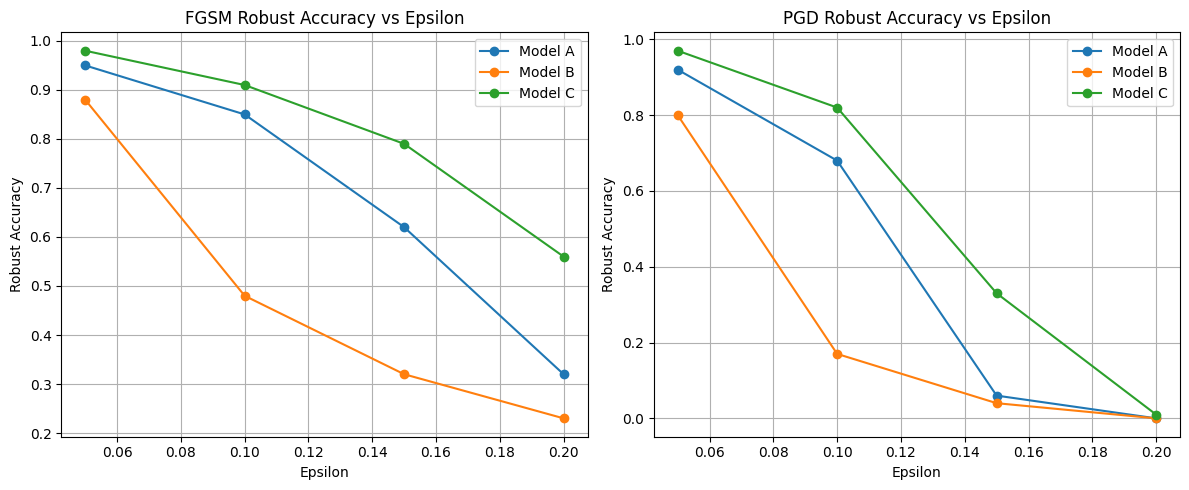

In [ ]:
import matplotlib.pyplot as plt

# Separate FGSM and PGD data
df_fgsm = df[["model", "eps", "FGSM_robust_acc"]]
df_pgd  = df[["model", "eps", "PGD_robust_acc"]]

plt.figure(figsize=(12,5))

# FGSM Plot
plt.subplot(1,2,1)
for m in ["A","B","C"]:
    subset = df[df["model"]==m]
    plt.plot(subset["eps"], subset["FGSM_robust_acc"], marker='o', label=f"Model {m}")
plt.title("FGSM Robust Accuracy vs Epsilon")
plt.xlabel("Epsilon")
plt.ylabel("Robust Accuracy")
plt.legend()
plt.grid(True)

# PGD Plot
plt.subplot(1,2,2)
for m in ["A","B","C"]:
    subset = df[df["model"]==m]
    plt.plot(subset["eps"], subset["PGD_robust_acc"], marker='o', label=f"Model {m}")
plt.title("PGD Robust Accuracy vs Epsilon")
plt.xlabel("Epsilon")
plt.ylabel("Robust Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**Robustness comparison across models**

Here is the breakdown of the robustness curves for the 3 models. Model B has the highest clean accuracy but robustness decreases the fastest as ε increases. Model C has significantly higher robust accuracy against both FGSM and PGD attacks.

This is an example of a trade-off between the accuracy of a model on a clean data vs robust accuracy. A model that is optimized for performance on clean data is not robust to adversarial attacks.

In [ ]:
eps_selected = 0.10

summary = df[df["eps"] == eps_selected][[
    "model",
    "FGSM_robust_acc",
    "PGD_robust_acc",
    "FGSM_mean_Linf",
    "FGSM_mean_L2",
    "PGD_mean_Linf",
    "PGD_mean_L2"
]].copy()

# use final clean test accs
clean_acc = {"A": 0.9893, "B": 0.9929, "C": 0.9908}
summary["Clean_acc"] = summary["model"].map(clean_acc)

# Reorder columns
summary = summary[[
    "model",
    "Clean_acc",
    "FGSM_robust_acc",
    "PGD_robust_acc",
    "FGSM_mean_Linf",
    "FGSM_mean_L2",
    "PGD_mean_Linf",
    "PGD_mean_L2"
]]

# Optional: make it good (percentages)
good = summary.copy()
for c in ["Clean_acc", "FGSM_robust_acc", "PGD_robust_acc"]:
    good[c] = (good[c] * 100).round(2)

for c in ["FGSM_mean_Linf", "FGSM_mean_L2", "PGD_mean_Linf", "PGD_mean_L2"]:
    good[c] = good[c].round(3)

good

,model,Clean_acc,FGSM_robust_acc,PGD_robust_acc,FGSM_mean_Linf,FGSM_mean_L2,PGD_mean_Linf,PGD_mean_L2
1,A,98.93,85.0,68.0,0.1,2.063,0.1,1.976
5,B,99.29,48.0,17.0,0.1,2.187,0.1,2.249
9,C,99.08,91.0,82.0,0.1,2.099,0.1,2.043


**Robustness comparison at ε = 0.10**

Results for. robustness metrics at ε = 0.10 are reported. such a level of perturbation, while large enough to distinguish between the models and yeild non-trivial test accuracy, is still relatively small and hence sufficiently close to the original clean samplpes. We see that model B has the highest clean test accuracy, however it experiences the largest decrease in accuracy, specifically under the PGD attack. On the other hand, Model C has the largest robustness metric values, and the smallest decrease in clean test accuracy.

our experiments show that the design of the architecture and/or of the regularization scheme can have a considerable impact on the robustness of the network. Moreover, they demonstrate that there is a significant gap between the high accuracy on clean examples that can be achieved by an optimally tuned model and the robustness of that same model to aversarial attacks.

**Per-digit robustness under PGD (ε = 0.10)**

We have seen that robustness can differ greatly across classes (digits). We now look at the per-digit robust accuracy under attack by the PGD attack with ε = 0.10 and why these differences occur.

In [ ]:
from collections import defaultdict

def per_class_robust_accuracy(classifier, eps):
    # Generate PGD attack
    pgd = ProjectedGradientDescent(
        estimator=classifier,
        eps=eps,
        eps_step=0.01,
        max_iter=40,
        targeted=False,
        num_random_init=1,
    )

    x_adv = pgd.generate(x=x)
    y_pred = classifier.predict(x_adv).argmax(axis=1)

    class_correct = defaultdict(int)
    class_total   = defaultdict(int)

    for true, pred in zip(y, y_pred):
        class_total[int(true)] += 1
        if true == pred:
            class_correct[int(true)] += 1

    class_acc = {digit: class_correct[digit] / class_total[digit]
                 for digit in sorted(class_total.keys())}

    return class_acc

eps_selected = 0.10

accA = per_class_robust_accuracy(clfA, eps_selected)
accB = per_class_robust_accuracy(clfB, eps_selected)
accC = per_class_robust_accuracy(clfC, eps_selected)

import pandas as pd

per_class_df = pd.DataFrame({
    "Digit": list(accA.keys()),
    "Model_A": list(accA.values()),
    "Model_B": list(accB.values()),
    "Model_C": list(accC.values())
})

per_class_df

PGD - Batches:   0%|          | 0/4 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/4 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/4 [00:00<?, ?it/s]

,Digit,Model_A,Model_B,Model_C
0,0,0.900000,0.400000,0.900000
1,1,0.636364,0.000000,0.909091
2,2,0.200000,0.000000,0.600000
3,3,0.857143,0.000000,1.000000
4,4,0.714286,0.214286,0.785714
5,5,0.727273,0.000000,1.000000
6,6,0.444444,0.111111,0.777778
7,7,0.928571,0.000000,0.785714
8,8,0.500000,0.750000,0.625000
9,9,0.833333,0.166667,0.666667


** Per class differences**

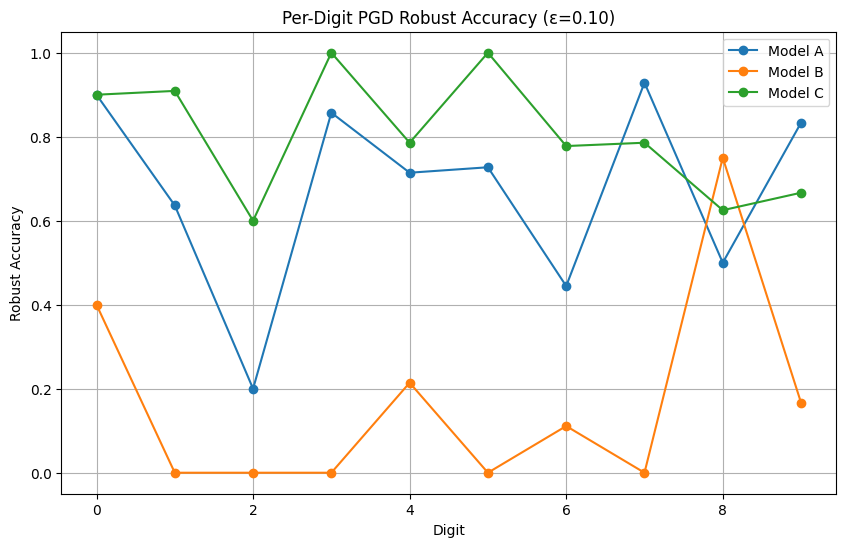

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(per_class_df["Digit"], per_class_df["Model_A"], marker='o', label="Model A")
plt.plot(per_class_df["Digit"], per_class_df["Model_B"], marker='o', label="Model B")
plt.plot(per_class_df["Digit"], per_class_df["Model_C"], marker='o', label="Model C")

plt.title("Per-Digit PGD Robust Accuracy (ε=0.10)")
plt.xlabel("Digit")
plt.ylabel("Robust Accuracy")
plt.legend()
plt.grid(True)
plt.show()

**Analysis**

Robustness Comparison at ε = 0.10

We select ε=0.10 because it produces meaningful separation between models without collapsing performance to near-zero (as seen at higher ε), making comparisons interpretable.
Clean and robust accuracy at the regularization level ε = 0.10. It is evident that different models behave differently. Model B has the highest clean accuracy of 99.29% but the lowest robust accuracy of 17% against the PGD attack. On the other hand, Model C achieves a much higher robust accuracy of 82% against the PGD attack and slightly lower clean accuracy.
Higher clean accuracy does not always translate to higher robustness. Model B just increases the depth of the network without performing any form of regularization. This makes the model more vulnerable to iterative gradient-based attacks. Model C on the other hand has dropout and weight decay that typically lead to a smoother decision surface and decrease overconfidence of the model, which also correlates with higher robustness.
Again for all models, we can see that PGD decreases the test accuracy more than FGSM which indicates that iterative attacks are stronger than one step attacks. We also notice that the gap between the test accuracy dropped by FGSM and PGD attacks is larger for Model B.

Per Digit Robustness Analysis We also looked at the robustness of individual classes or per digit and we observed that the classes that are easily attacked by the adversarial samples are distinct. Also we can see that some of the digits are more robust than the others and the other digits suffer heavily. Which means the class geometries of the different digits are also an important factor for the samples to be easily movable to the opposite side of the decision boundary.

Here, we investigate the relationship between robustness and adversarial vulnerability. We find a large variability in robustness across the dataset and that some classes are easier to attack. This shows that the robustness is not uniform across classes and that some classes are more fragile.



**Discussion and Limitations**

The robustness of a neural network can dramatically change depending on the network structure and type of attack that is considered. The three networks have the same high clean accuracy on MNIST but have very different robustness to the attacks we are considering. Specifically, Model C is more robust to the FGSM and PGD attacks. hus, it is crucial to investigate the impact of different network structures and design decisions and how they interact with the different types of attacks.

here are a number of limitations to this evaluation. We evaluated model performance on a random subset of 100 test images. We also only attempted to evaluate model performance against two attacks (with their hyperparameters left at their default values, and not optimally tuned for these models or images). Ideally a more robust validation would be run on a larger validation set with stronger attacks such as AutoAttack.  Finally, none of the models we evaluate were adversarially trained. Adversarial training is a well known technique for improving the robustness of models, even in the absence of strong attacks.